# Capstone Project Starter Notebook

## Applied Python for Data Analysis

This notebook is a scaffold for your capstone project. It is designed to help you organize your work, document your thinking, and complete a clear data analysis workflow.

You should replace the placeholder text, complete the TODOs, and add your own analysis throughout.

---

## Capstone Goal

Your project should answer **one clear analytical question** using Python and data.

You will:
- Load and inspect your dataset
- Clean and prepare the data
- Explore the data with summary statistics and visualizations
- Generate insights and recommendations
- Optionally build a simple predictive model


## 1. Problem Statement

Write your problem statement below.

Use the SMART framework:

- **Specific:** What exactly are you trying to answer?
- **Measurable:** What data will you use?
- **Achievable:** Can this be answered with your dataset?
- **Relevant:** Why does this matter?
- **Time-bound:** Is there a time component?

### Problem Statement

> I am a data analyst for an e-commerce company trying to increase revenue. I am preparing a presentation for upper management to analyze the last  year of transaction data to identify the top three key factors impacting our revenue. This will determine our future growth plan for the upcoming calendar year and I will provide a 1 year projection based on the data. Specifically, my goals are the analyze three factors:
>  1) Quantify the most impactful variables that have the strongest correlation with our revenue overall (specifically I will look at if there is a relationship between weekend sales, product category or marketing category and revenue).
>  2) Engage in a customer segmentation exercise to determine how much to invest in our VIP customers for the upcoming year based on analysis of their impact on profitability.
>  3) Determining the effectiveness of our pricing strategy and whether discounts help or hurt our overall revenue levels and drive more sales.

### Audience

> **Who is this analysis for?** This anaylsis is for the CFO of the company, the CMO and the head of sales. The outputs will impact their marketing and pricing strategy for the upcoming calendar year.

### Primary Business / Analytical Question

> **What main question will your project answer?** What customers, product or pricing levers should the company prioritize in FY 2026 to maximize revenue growth for the year without eroding margin (i.e. increased returns and discounts without increasing volume or client penetration).


## 2. Imports and Setup

Run this cell first.

You may add additional libraries if needed.


In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File path tools
from pathlib import Path


## 3. File Paths

Update the file path below so it points to your raw dataset.

Recommended project structure:

```text
data/
├── raw/
│   └── your_dataset.csv
└── processed/
    └── cleaned_dataset.csv
```


In [117]:
# raw data
raw_data_path = Path("../data/raw/capstone_dataset.csv")

#need to create a processed/cleaned dataset, but so far I am just opening and checking the dataset

## 4. Load the Dataset

Load your dataset into a pandas DataFrame.

If your file is not a CSV, adjust the code accordingly.


In [118]:
df = pd.read_csv(raw_data_path)


## 5. Initial Data Inspection

Use this section to understand the basic structure of your dataset.

Questions to answer:
- **How many rows and columns are there?** 500 rows and 13 columns
- **What does each row represent?** A single purchase or return 
- **What are the column names?** transaction_id, date, customer_id, customer_segment, product_category, product_price, quantity, discount_applied, marketing_channel, region, total_revenue, customer_satisfaction, returned
- **What data types are present?** There are three data types: strings, integers and floats. Date is stored as a string and I need to convert that. Customer and transcation IDs are also strings vs floats, however given they have numbers and text, I do not believe I will need to convert them to anything. 
- **Are there missing values?** Discount applied has 5 missing values and customer satisfaction has 10 missing values.


In [119]:
# Shape of the dataset
df.shape


(500, 13)

In [120]:
# Column names
df.head()


,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.0,0
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.0,0
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.0,0
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.0,0
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.0,0


In [121]:
# Data types and missing values

df.info()

df.isnull().sum()

# notes for cleaning later-- i need to change the transaction id from a string into a float, change date from string, change customer id into float and returned is probably a binary number
#looks like i have five nulls in discount and 10 in customer satisfaction i am going to need to inspect or clean up

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         500 non-null    str    
 1   date                   500 non-null    str    
 2   customer_id            500 non-null    str    
 3   customer_segment       500 non-null    str    
 4   product_category       500 non-null    str    
 5   product_price          500 non-null    float64
 6   quantity               500 non-null    int64  
 7   discount_applied       495 non-null    float64
 8   marketing_channel      500 non-null    str    
 9   region                 500 non-null    str    
 10  total_revenue          500 non-null    float64
 11  customer_satisfaction  490 non-null    float64
 12  returned               500 non-null    int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 78.3 KB


transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64

In [122]:
# Summary statistics for numeric columns
df.describe()


,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned
count,500.000000,500.000000,495.000000,500.000000,490.000000,500.000000
mean,266.594660,3.032000,0.075051,769.146000,3.865306,0.072000
std,142.045942,1.423738,0.070773,594.522332,0.638105,0.258747
min,15.120000,1.000000,0.000000,10.000000,2.000000,0.000000
25%,146.555000,2.000000,0.000000,282.042500,3.000000,0.000000
50%,272.035000,3.000000,0.050000,644.250000,4.000000,0.000000
75%,389.152500,4.000000,0.125000,1181.647500,4.000000,0.000000
max,499.690000,5.000000,0.250000,2469.200000,5.000000,1.000000


In [156]:
# Summary statistics for non-numeric columns
df.describe(include='object')

#This is telling me I only have 268 unique dates and 472 unique customers, three tiers of customer segments and six types of products

# the red message is not a real error message and compatability message so i will ignore for this exercise

/var/folders/wx/1v3_66n56yz83m7c_33v0r2w0000gn/T/ipykernel_5813/4194008803.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,transaction_id,date,customer_id,customer_segment,product_category,marketing_channel,region
count,500,500,500,500,500,500,500
unique,500,268,472,3,6,6,5
top,TXN-00180,2025-05-16,CUST-2552,Returning,Beauty,Direct,West
freq,1,8,4,210,94,95,108


In [124]:
# Missing values by column
df.isnull().sum()

# ran above

transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64

In [125]:
# Duplicate rows 
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate transaction IDs: {df['transaction_id'].duplicated().sum()}")


Duplicate rows: 0
Duplicate transaction IDs: 0


In [126]:
#initial theory I assumed i would analyze three years of data, checking full date range here

df['date'].min(), df['date'].max()

# i need to go back and revise to one year of data in my thesis 

('2025-01-01', '2026-01-01')

In [127]:
# i want to look at customer segments since that needs to be clean for my analysis 
for col in ['customer_segment', 'product_category', 'marketing_channel', 'region']:
    print(f"\n{col}:")
    print(df[col].value_counts())


customer_segment:
customer_segment
Returning    210
New          207
VIP           83
Name: count, dtype: int64

product_category:
product_category
Beauty           94
Electronics      88
Books            87
Home & Garden    82
Clothing         81
Sports           68
Name: count, dtype: int64

marketing_channel:
marketing_channel
Direct            95
Social Media      92
Organic Search    90
Email             84
Referral          78
Paid Search       61
Name: count, dtype: int64

region:
region
West       108
Central    104
North       99
South       96
East        93
Name: count, dtype: int64


## 6. Data Cleaning

Use this section to clean your dataset.

Common cleaning tasks:
- Fix column names
- Convert data types
- Handle missing values
- Remove duplicates
- Fix inconsistent categories
- Create helpful new columns

Document every major cleaning decision in markdown.


In [128]:
# Make a copy before cleaning
df_clean = df.copy()


In [129]:
# Optional: standardize column names
# I picked the pretty clean dataset provided, so no need to standardize based on initial analyiss 

In [130]:
# TODO: Convert date columns if your dataset has them
# Example:
# df_clean["date"] = pd.to_datetime(df_clean["date"])

df_clean["date"] = pd.to_datetime(df_clean["date"])

# Verify
print(df_clean["date"].dtype)
df_clean["date"].head()



datetime64[us]


0   2025-01-01
1   2025-01-02
2   2025-01-02
3   2025-01-02
4   2025-01-04
Name: date, dtype: datetime64[us]

In [131]:
# TODO: Handle missing values
# Example strategies:
# df_clean["numeric_column"] = df_clean["numeric_column"].fillna(df_clean["numeric_column"].median())
# df_clean["category_column"] = df_clean["category_column"].fillna("Unknown")

# Fill missing discount_applied with 0 (assumption: missing = no discount applied)
df_clean["discount_applied"] = df_clean["discount_applied"].fillna(0)

# Leave customer_satisfaction NaNs as they are vs backfilling with zero or a mean — backfilling would impact scores in the wrong way for any analysis.

print(df_clean.isnull().sum())




transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          0
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64


In [132]:
# TODO: Remove duplicate rows if appropriate
# df_clean = df_clean.drop_duplicates()

# No duplicates were found in inspection. Running just to be safe and check I did not miss anything.
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"{before - after}")



0


In [133]:
# TODO: Check categorical columns for inconsistent labels
# Example:
# df_clean["category_column"].value_counts()

# Replace "category_column" with an actual column name

#  i already ran it up in 23 when i was checking out the data to ensure categories werent capitalized or had spaces, but running again. No issues or dupes with customer segments or product categories or marketing channels to clean
for col in ['customer_segment', 'product_category', 'marketing_channel', 'region']:
    print(f"\n{col}:")
    print(df[col].value_counts())




customer_segment:
customer_segment
Returning    210
New          207
VIP           83
Name: count, dtype: int64

product_category:
product_category
Beauty           94
Electronics      88
Books            87
Home & Garden    82
Clothing         81
Sports           68
Name: count, dtype: int64

marketing_channel:
marketing_channel
Direct            95
Social Media      92
Organic Search    90
Email             84
Referral          78
Paid Search       61
Name: count, dtype: int64

region:
region
West       108
Central    104
North       99
South       96
East        93
Name: count, dtype: int64


In [134]:
# Optional: create new useful columns
# Adding in the estimated revenue suggesting:
df_clean["estimated_revenue"] = (
     df_clean["product_price"] 
     * df_clean["quantity"] 
    * (1 - df_clean["discount_applied"])
 )

# Time ones -- adding in month and then is it on the weekend or weekday
# Adding in month column for time-based aggregations
df_clean["month"] = df_clean["date"].dt.to_period("M")
df_clean["is_weekend"] = df_clean["date"].dt.dayofweek.isin([5, 6]).astype(int)


# Adding a binary flag for whether a discount was applied in addition to the % discount
df_clean["binary_discount"] = (df_clean["discount_applied"] > 0).astype(int)


# Adding in revenue per unit to combine them all to figure out how much revenue was made on a transaction after a discount was applied per unit
df_clean["revenue_per_unit"] = df_clean["total_revenue"] / df_clean["quantity"]
 
 

# checking what was added
print(df_clean.info())
print(f"\nShape after cleaning: {df_clean.shape}")





<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         500 non-null    str           
 1   date                   500 non-null    datetime64[us]
 2   customer_id            500 non-null    str           
 3   customer_segment       500 non-null    str           
 4   product_category       500 non-null    str           
 5   product_price          500 non-null    float64       
 6   quantity               500 non-null    int64         
 7   discount_applied       500 non-null    float64       
 8   marketing_channel      500 non-null    str           
 9   region                 500 non-null    str           
 10  total_revenue          500 non-null    float64       
 11  customer_satisfaction  490 non-null    float64       
 12  returned               500 non-null    int64         
 13  estimated_revenu

In [135]:
# i played around with if revenue was missing things that i needed to take into account (it was not) and also was initially playing around w a "has discount" field that was the same as binary discount, dropping those extra columns that dont make sense
#df_clean = df_clean.drop(columns=["expected_revenue", "revenue_gap", "has_discount"])
#print(df_clean.columns.tolist())

#dont need anymore so just keeping to show my work/ in case the columns pop back up

### Cleaning Summary

Write a short summary of your cleaning steps.
  
- Converted date from string to date so I can analyze trends by month and also I can see if sales spike on weekends vs weekdays.
- Filled 5 missing discount_applied values with 0 (missing = no discount applied).
- Retained 10 missing customer_satisfaction values as N/A. Evaluated whether to backfill and putting as zero or mean would skew data, and it is not central to my analysis.
- No duplicate labels for customer_segment, product_category, marketing_channel, region that needed to be fixed for spacing or capitalization issues.
- Investigated whether total_revenue matched a calculated expected_revenue = (price × quantity × (1 − discount)). Was not material, so dropped the additional columns.
- Added derived columns to support the three analytical workstreams:
  - month — for monthly trend analysis
  - is_weekend — for weekday vs. weekend comparisons
  - revenue_per_unit — separates per-item pricing to later analyze if discounts drive higher volume purchases
  - has_discount — binary flag for a discount since initial field is the % discount

**TODO: Describe what you cleaned and why.**
-  Cleaning steps above explain each column and why I decided to clean or add in a column for future analysis. This is going to help when I analyze if certain factors impact revenue (correlation of factors, such as month or weekend as well as pricing with revenue) and when I analyze if discounts impact and drive revenue overall (revenue_per_unit is going to be key as i work through that).


In [136]:
# Save cleaned dataset 
df_clean.to_csv("../data/processed/capstone_dataset_cleaned.csv", index=False)
print("Cleaned dataset saved to ../data/processed/capstone_dataset_cleaned.csv")


Cleaned dataset saved to ../data/processed/capstone_dataset_cleaned.csv


## 7. Exploratory Data Analysis

Use EDA to answer your main question.

Your project should include:
- Summary statistics
- At least 2 meaningful visualizations
- At least 2 strong insights
- Clear interpretation of each chart or table

Do not just make charts. Explain what they mean.


### 7.1 Univariate Analysis

Analyze one variable at a time.

Examples:
- Distribution of revenue
- Count of product categories
- Count of customer segments
- Distribution of sale prices


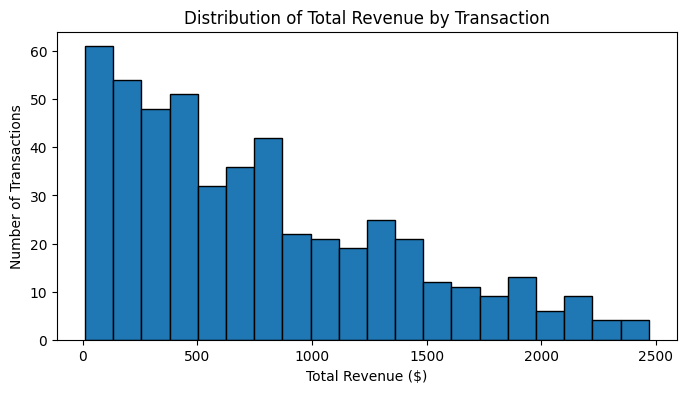

count     500.000000
mean      769.146000
std       594.522332
min        10.000000
25%       282.042500
50%       644.250000
75%      1181.647500
max      2469.200000
Name: total_revenue, dtype: float64

In [137]:
# TODO: I want to analyze dsitribution of revenue

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_clean["total_revenue"], bins=20, edgecolor="black")
plt.title("Distribution of Total Revenue by Transaction")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Number of Transactions")
plt.show()

df_clean["total_revenue"].describe()



**Main takeaway from this histogram is that there is a really strong right skew to the data, which initially implies that a small amount of big dollar transactions between $1k and $2.5k drive nearly as much revenue as a much higher volume of smaller ticket purchases.** This reinforces that I should keep digging to analyze if VIPs are driving those purchases or if there are other factors showing correlation.

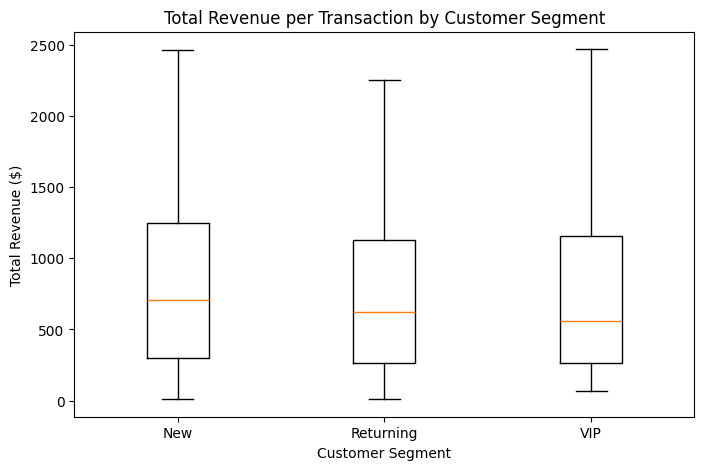

                  count        mean         std    min       25%     50%  \
customer_segment                                                           
New               207.0  805.060242  618.878005  10.00  302.7600  706.43   
Returning         210.0  733.353143  557.607675  10.92  266.8675  624.75   
VIP                83.0  770.136988  624.257347  69.08  267.5650  560.21   

                       75%      max  
customer_segment                     
New               1246.830  2466.90  
Returning         1131.360  2255.82  
VIP               1158.695  2469.20  


In [138]:
# Now lets look at the VIPs and types of customers
segment_counts = df_clean["customer_segment"].value_counts()

import matplotlib.pyplot as plt
segments = df_clean["customer_segment"].unique()
data_by_segment = [df_clean[df_clean["customer_segment"] == seg]["total_revenue"] for seg in segments]

plt.figure(figsize=(8, 5))
plt.boxplot(data_by_segment, tick_labels=segments)
plt.title("Total Revenue per Transaction by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue ($)")
plt.show()

# Supporting summary stats
print(df_clean.groupby("customer_segment")["total_revenue"].describe())


**My main takeaway from this boxplot is that there are only 83 VIPs/less tha half of new or returning customers, but they drive nearly the same amount of sales as the other client types.** Again, at this stage we have not proved correlation and definitely not causation, but it looks like VIPs are likely going to be an important factor to analyze. Also, the boxplot isn't really what effectively shows this, its the summary table at the bottom. If I could start from scratch a better visualization would be a pure bar chart vs a histogram or box plot, but I did not want to go too far from what we learned for the class and applying those visualizations. Also it looks like VIPs may buy more volume vs just buying higher priced ticket items, but that is something we need to explore.

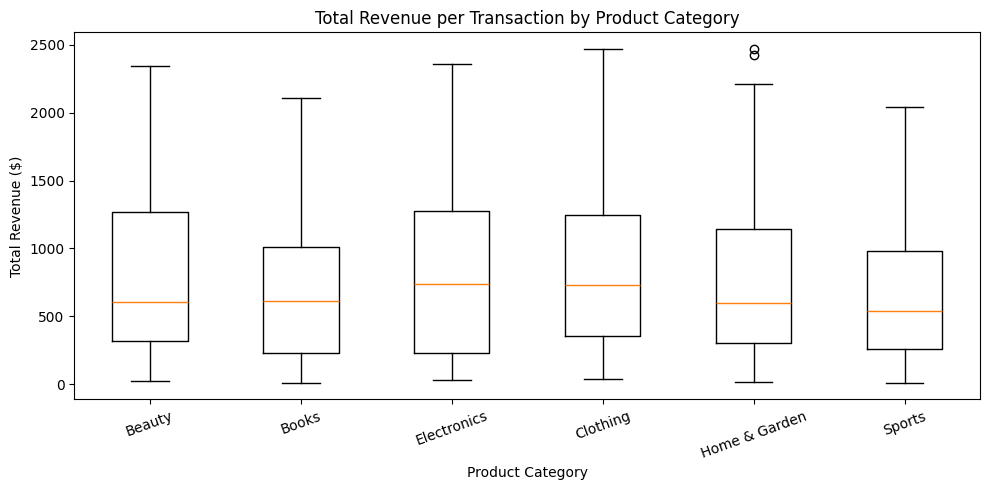

                  count        mean         std    min       25%      50%  \
product_category                                                            
Beauty             94.0  791.067447  619.498319  22.96  316.8700  606.650   
Books              87.0  697.599425  537.522563  10.92  231.1350  611.830   
Clothing           81.0  820.771111  562.593027  37.86  353.5500  731.600   
Electronics        88.0  808.420000  655.433381  33.02  225.8825  738.010   
Home & Garden      82.0  801.477683  630.111030  15.12  300.7200  595.125   
Sports             68.0  679.072353  539.489987  10.00  256.2700  541.910   

                        75%      max  
product_category                      
Beauty            1269.0250  2341.68  
Books             1007.8800  2106.74  
Clothing          1246.4600  2466.90  
Electronics       1275.7675  2360.05  
Home & Garden     1142.1550  2469.20  
Sports             981.6400  2039.94  


In [157]:
# Now lets analyze product categories
categories = df_clean["product_category"].unique()
data_by_cat = [df_clean[df_clean["product_category"] == cat]["total_revenue"] for cat in categories]

plt.figure(figsize=(10, 5))
plt.boxplot(data_by_cat, tick_labels=categories)
plt.title("Total Revenue per Transaction by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(df_clean.groupby("product_category")["total_revenue"].describe())


**This boxplot really is not very exciting for an insight but very helfpul for our analysis-- the counts of each of the product types are pretty similar, and it does not seem to be a strong driver of revenue.** Both the mean and the count is pretty evenly distributed, so I am less likely to note product category will be a signficant factor in driving revenue (i.e. the takeaway will not be to focus marketing or stocking on a specific product type as the revenue driver.)

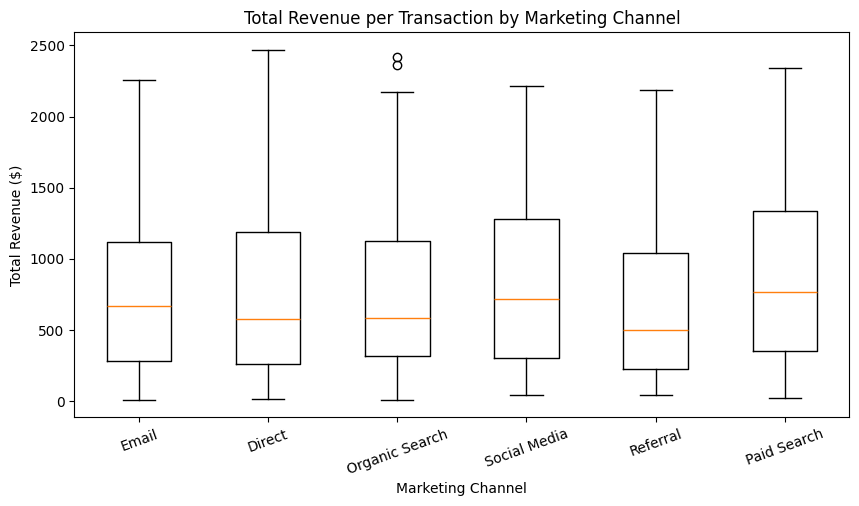

                   count        mean         std    min       25%     50%  \
marketing_channel                                                           
Direct              95.0  766.948947  644.198298  15.12  263.8050  577.75   
Email               84.0  753.181429  583.795629  10.00  280.6225  667.30   
Organic Search      90.0  758.972667  601.567432  10.92  314.5775  585.91   
Paid Search         61.0  845.698361  610.852642  22.96  353.5500  767.69   
Referral            78.0  679.919872  530.146323  40.08  229.0275  499.98   
Social Media        92.0  820.833913  589.143140  43.30  300.6200  719.59   

                         75%      max  
marketing_channel                      
Direct             1191.4900  2469.20  
Email              1118.7975  2255.82  
Organic Search     1123.6750  2421.58  
Paid Search        1337.9900  2341.68  
Referral           1038.0900  2187.25  
Social Media       1278.9075  2214.11  


In [140]:
# Since product isnt a driver, lets see if there is a stronger relationship with marketing channels
channels = df_clean["marketing_channel"].unique()
data_by_channel = [df_clean[df_clean["marketing_channel"] == ch]["total_revenue"] for ch in channels]

plt.figure(figsize=(10, 5))
plt.boxplot(data_by_channel, tick_labels=channels)
plt.title("Total Revenue per Transaction by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=20)
plt.show()

print(df_clean.groupby("marketing_channel")["total_revenue"].describe())


This one is more interesting, there's more variation here but again I do not think the boxplot is really showing the effective visual for me to analyize. I looked up and asked AI to help me with visualizing a horizontal bar chart that shows the overalll volumes and revenue visually right next to each other to help dig into which channels are super accretive from a revenue perspective but lower volume. This one had a stronger relationship, and the box and whisker plot just was not showing it for me to look more into the relationship.

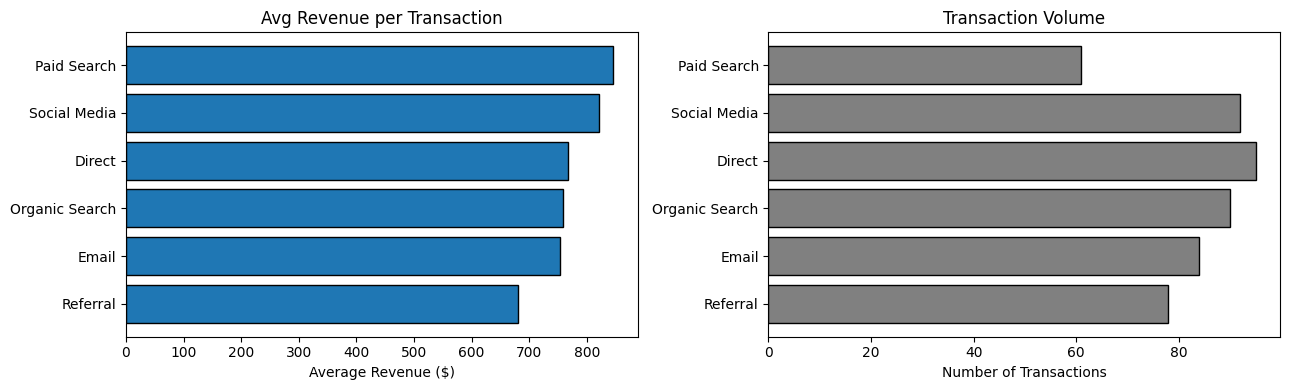

In [142]:
channel_summary = df_clean.groupby("marketing_channel").agg(
    avg_revenue=("total_revenue", "mean"),
    transaction_count=("transaction_id", "count")
).sort_values("avg_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(channel_summary.index, channel_summary["avg_revenue"], edgecolor="black")
axes[0].set_title("Avg Revenue per Transaction")
axes[0].set_xlabel("Average Revenue ($)")
axes[0].invert_yaxis()

axes[1].barh(channel_summary.index, channel_summary["transaction_count"], edgecolor="black", color="gray")
axes[1].set_title("Transaction Volume")
axes[1].set_xlabel("Number of Transactions")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**This is more effective visually than the boxplot.** It shows paid search has the highest revenue and lowest volume, and social media follows with the second highest revenue per transaction and a much higher transaction volume. This is a relationship I will continue to analyze since it looks like it will have a fruitful answer for the CMO.

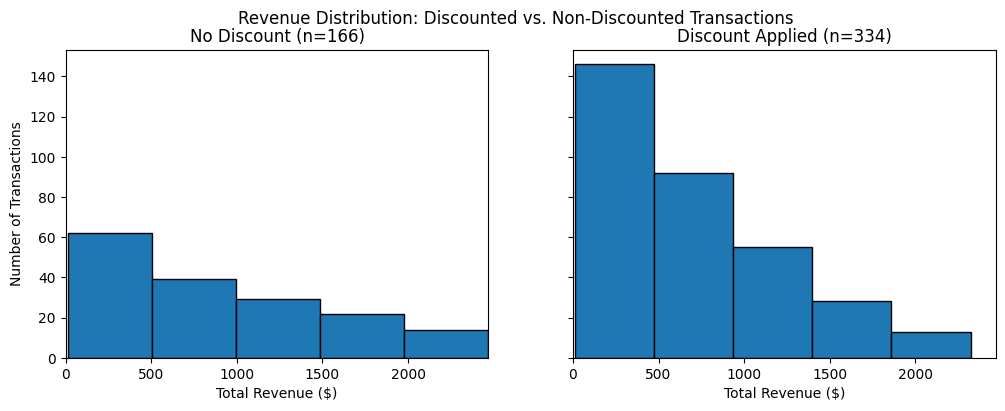

                 transactions  avg_revenue  median_revenue  avg_quantity  \
binary_discount                                                            
0                         166   912.372108         770.870      3.216867   
1                         334   697.961766         590.425      2.940120   

                 return_rate  
binary_discount               
0                   0.084337  
1                   0.065868  


In [143]:
#Okay now lets analyze-- do discounts matter?

import matplotlib.pyplot as plt

no_disc = df_clean[df_clean["binary_discount"] == 0]["total_revenue"]
with_disc = df_clean[df_clean["binary_discount"] == 1]["total_revenue"]


x_max = df_clean["total_revenue"].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(no_disc, bins=5, edgecolor="black")
axes[0].set_title(f"No Discount (n={len(no_disc)})")
axes[0].set_xlabel("Total Revenue ($)")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xlim(0, x_max)

axes[1].hist(with_disc, bins=5, edgecolor="black")
axes[1].set_title(f"Discount Applied (n={len(with_disc)})")
axes[1].set_xlabel("Total Revenue ($)")
axes[1].set_xlim(0, x_max)

plt.suptitle("Revenue Distribution: Discounted vs. Non-Discounted Transactions")
plt.show()

# Supporting stats
print(df_clean.groupby("binary_discount").agg(
    transactions=("transaction_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    median_revenue=("total_revenue", "median"),
    avg_quantity=("quantity", "mean"),
    return_rate=("returned", "mean")
))


**Interesting angle here is truly how many transactions occur with a discount**. 67% of transactions are discounted-- but both histograms are right skewed heavily. Discounted transactions bring in $214 less on each transaction ($697 vs $912) but it doesn't look like it is (again this is just visualization so nothing is causation) even driving much higher volumes of purchases. Return rate is slightly lower but not by much.

         transactions  total_revenue  avg_revenue  avg_quantity
Weekday           366      281806.53   769.963197      3.024590
Weekend           134      102766.47   766.913955      3.052239


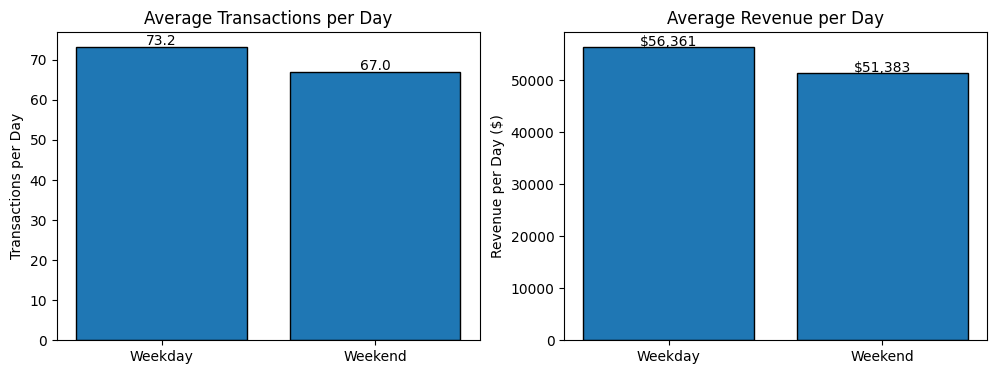

In [144]:
## last one-- Do people shop more on the weekend?

import matplotlib.pyplot as plt

# Summary stats
weekend_summary = df_clean.groupby("is_weekend").agg(
    transactions=("transaction_id", "count"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    avg_quantity=("quantity", "mean")
)
weekend_summary.index = ["Weekday", "Weekend"]
print(weekend_summary)

# Per-day averages (since there are 5 weekdays and 2 weekend days)
weekend_summary["days_in_period"] = [5, 2]
weekend_summary["avg_transactions_per_day"] = weekend_summary["transactions"] / weekend_summary["days_in_period"]
weekend_summary["avg_revenue_per_day"] = weekend_summary["total_revenue"] / weekend_summary["days_in_period"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Average transactions per day
bars1 = axes[0].bar(weekend_summary.index, weekend_summary["avg_transactions_per_day"], edgecolor="black")
axes[0].set_title("Average Transactions per Day")
axes[0].set_ylabel("Transactions per Day")
for bar, v in zip(bars1, weekend_summary["avg_transactions_per_day"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}", ha="center")

# Average revenue per day
bars2 = axes[1].bar(weekend_summary.index, weekend_summary["avg_revenue_per_day"], edgecolor="black")
axes[1].set_title("Average Revenue per Day")
axes[1].set_ylabel("Revenue per Day ($)")
for bar, v in zip(bars2, weekend_summary["avg_revenue_per_day"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 200, f"${v:,.0f}", ha="center")
 
plt.show()


Pretty surprising to me-- not a strong relationship between sales on weekends. Sales and revenue are actually lower on the weekend, albeit a small amount. This tells me not to waste time here- will disregard and spend the analysis on the discount strategy, the VIPs and the marketing channels.

### 7.2 Group-Based Analysis

Use `.groupby()` to compare groups.

Examples:
- Average revenue by customer segment
- Return rate by product category
- Average price by neighborhood
- Life expectancy by continent


In [145]:
# Thesis 1 -- Quantify the most impactful factors that have the strongest correlation with our revenue overall. Grouping by revenue by product category


category_summary = df_clean.groupby("product_category").agg(
    transactions=("transaction_id", "count"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    median_revenue=("total_revenue", "median"),
    return_rate=("returned", "mean")
).sort_values("total_revenue", ascending=False)

print(category_summary)


                  transactions  total_revenue  avg_revenue  median_revenue  \
product_category                                                             
Beauty                      94       74360.34   791.067447         606.650   
Electronics                 88       71140.96   808.420000         738.010   
Clothing                    81       66482.46   820.771111         731.600   
Home & Garden               82       65721.17   801.477683         595.125   
Books                       87       60691.15   697.599425         611.830   
Sports                      68       46176.92   679.072353         541.910   

                  return_rate  
product_category               
Beauty               0.053191  
Electronics          0.136364  
Clothing             0.037037  
Home & Garden        0.060976  
Books                0.068966  
Sports               0.073529  


**Product category summary**:Product category is not a meaningful revenue driver. Average and median revenue per transaction are really similar across all six categories (~$680-$820 range), and transaction counts are tightly clustered (68-94). This is itself an actionable finding: we should not revisit selling a certain product (we saw this in visualization.

In [146]:
# Thesis 2 Engage in a customer segmentation exercise -- Grouping by customer segment
segment_summary = df_clean.groupby("customer_segment").agg(
    transactions=("transaction_id", "count"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    median_revenue=("total_revenue", "median"),
    avg_quantity=("quantity", "mean"),
    return_rate=("returned", "mean")
).sort_values("total_revenue", ascending=False)

print(segment_summary)


                  transactions  total_revenue  avg_revenue  median_revenue  \
customer_segment                                                             
New                        207      166647.47   805.060242          706.43   
Returning                  210      154004.16   733.353143          624.75   
VIP                         83       63921.37   770.136988          560.21   

                  avg_quantity  return_rate  
customer_segment                             
New                   3.125604     0.067633  
Returning             2.871429     0.090476  
VIP                   3.204819     0.036145  


**Customer segment category**: VIPs make up only 17% of transactions (83 of 500) but contribute significant total revenue, above new and returning customers. It looks like VIP's revenue is not driven from larger baskets, but potentially purchase frequency. CMO reccomendation should be to target investment in VIPs but we need to test if they should increase the amount spent vs just focus on retention and volume.


In [147]:
# Thesis 3- Determining the effectiveness of our pricing strategy and whether discounts help or hurt our overall revenue levels and drive more sales.
# Should we keep giving this many discounts... to VIPs?
discount_segment_summary = df_clean.groupby(["customer_segment", "binary_discount"]).agg(
    transactions=("transaction_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    median_revenue=("total_revenue", "median"),
    avg_quantity=("quantity", "mean"),
    return_rate=("returned", "mean")
)

print(discount_segment_summary)

# Discount frequency by segment — are we giving the most discounts to our best customers?
print("\n% of transactions with discount, by segment:")
print((df_clean.groupby("customer_segment")["binary_discount"].mean() * 100))



                                  transactions  avg_revenue  median_revenue  \
customer_segment binary_discount                                              
New              0                          70   942.716286         766.070   
                 1                         137   734.725036         649.970   
Returning        0                          74   869.485000         796.645   
                 1                         136   659.281397         592.285   
VIP              0                          22   960.079091         685.565   
                 1                          61   701.633279         512.960   

                                  avg_quantity  return_rate  
customer_segment binary_discount                             
New              0                    3.314286     0.128571  
                 1                    3.029197     0.036496  
Returning        0                    3.013514     0.054054  
                 1                    2.794118     0.1102

**Discounts and tying it to VIPs**: VIPs receive the most discounts of any segment 73% and lose the most revenue when discounted -27%. Given the visualizations earlier, we are giving away way too many discounts on the majority of our products, and it looks like it is not really driving VIPs to buy more volume and increase revenue. We can likely reccomend discounting less, and especially work on other ways to develop and retain relationships with VIPs that are not discounting product to increase revenue. We need to continue to test in relationship analysis, but this looks like the strongest relationship and potential reccomendation to test so far.

**End of section findings:**

1. Strongest relationship of what we've visualized and grouped bys is around VIPs and also the firms discounting strategy.
2. For VIPs- they seem to have a stronger relationship than product type but draw significant revenue. It seems to be driven off of repeat or frequent purchases vs bigger baskets.
3. VIPs receive the highest discount frequency of transactions. The company is discounting its most loyal customers more aggressively than its acquisition to drive more full priced sales w new clients.
4. VIPs without discounts average $960 per transaction.  Discounted VIPs experience larger drop than New (-22%) or Returning (-24%) customers experience.



### 7.3 Relationship Analysis

Explore relationships between variables.

Examples:
- Revenue vs discount
- Sale price vs square footage
- Satisfaction vs return status


Text(0.5, 1.0, 'Correlation Matrix of Factors')

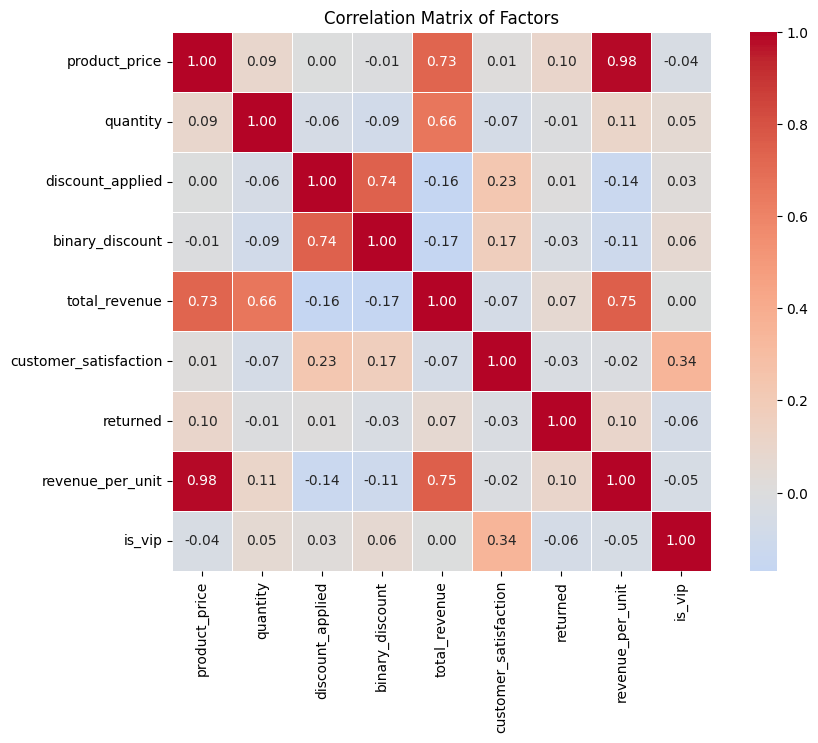

In [148]:
# lets look at a correlation table to now look at the strength of the relationship between all of the different vairables
 
import seaborn as sns

# Since VIP is a string and the core of my thesis now-- i need it in the correlation table. i created binary VIP flag for correlation analysis so i can look at it in the correlation table. right now its a string
df_clean["is_vip"] = (df_clean["customer_segment"] == "VIP").astype(int)

#create the correlation table using seaborn
numeric_cols = ["product_price", "quantity", "discount_applied", "binary_discount",
                "total_revenue", "customer_satisfaction", "returned", 
                "revenue_per_unit", "is_vip"]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=0.5)
plt.title("Correlation Matrix of Factors")


**Correlation Matrix Findings:**

The heatmap statistically validates several of our theories that we found from visualizations, and gave an interesting relationship with VIPs and transaction revenue:

1. **Product price (0.73) and quantity (0.66) are the strongest revenue drivers.** Both relationships are strong and positive.

2. **Discounts show a weak negative correlation with revenue.** This reinforces we likely need to stop discounting so much, because it is not driving more volume and it is potentially eroding our profit.

3. **VIP status has zero correlation with per-transaction revenue.** This is the most shocking to me.  VIPs are not bigger per-transaction spenders. They shop frequently, but do not spend more on an average transaction.

4. **VIPs report higher customer satisfaction.** This was not part of initial thesis but interesting to know. VIPs are loyal, so potentially we can lean on other levels vs discount to keep them satisfy and increase revenue.

5. **Returns are not/ have by far the weakest correlation with transaction size.**  Not a signficant correlation. Reinforces our decision to not dive too much into returns and hone in on VIPs and discounts.


**We have some strong takeaways from the correlation table** now I am going to test out our two strongest theories with t tests to determine not just if there's a correlation, but to determine if these relationships are statistically significant and not random chance in the data.

In [149]:
# Running two t tests based on our strongest theories

# T Test 1: Is there a real relationship between discounting and revenue

from scipy import stats

discounted = df_clean[df_clean["binary_discount"] == 1]["total_revenue"]
not_discounted = df_clean[df_clean["binary_discount"] == 0]["total_revenue"]

t_stat, p_value = stats.ttest_ind(discounted, not_discounted, equal_var=False)

print(f"Discounted mean: ${discounted.mean():.2f}")
print(f"Non-discounted mean: ${not_discounted.mean():.2f}")
print(f"Difference: ${not_discounted.mean() - discounted.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}") 


Discounted mean: $697.96
Non-discounted mean: $912.37
Difference: $214.41
T-statistic: -3.569
P-value: 0.0004


In [150]:
# T Test 2: Is there a real relationship between VIPs and revenue

vip_revenue = df_clean[df_clean["is_vip"] == 1]["total_revenue"]
non_vip_revenue = df_clean[df_clean["is_vip"] == 0]["total_revenue"]

t_stat, p_value = stats.ttest_ind(vip_revenue, non_vip_revenue, equal_var=False)

print(f"VIP mean: ${vip_revenue.mean():.2f}")
print(f"Non-VIP mean: ${non_vip_revenue.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}") 

VIP mean: $770.14
Non-VIP mean: $768.95
T-statistic: 0.016
P-value: 0.9873


**T- Test Takeaways:**
- For the first t-test, the relationship between discounting and revenue was statistically significant. 
- For my second t-test, the relationship between VIP and non-VIP transaction revenue is not statistically significant. However, we already knew that, so I need to revise the t-test to test if the relationship between VIP total revenue is significant instead of just by transaction.

- Through running this i realized I tested the wrong thing- our theory is that VIPs dont spend more per transaction, they spend more overall through repeated purchases.

In [151]:
# To fix the second t -test-- need to ggregate to the customer level: total annual revenue per customer
customer_totals = df_clean.groupby("customer_id").agg(
    total_annual_revenue=("total_revenue", "sum"),
    transaction_count=("transaction_id", "count"),
    segment=("customer_segment", "first")
).reset_index()

# Quick look at the aggregated data
print(customer_totals.head())
print(f"\nTotal unique customers: {len(customer_totals)}")
print(f"\nCustomers by segment:")
print(customer_totals["segment"].value_counts())


  customer_id  total_annual_revenue  transaction_count    segment
0   CUST-1001               1586.98                  1        New
1   CUST-1006                785.49                  1  Returning
2   CUST-1022                305.88                  1        New
3   CUST-1024               2128.93                  1        New
4   CUST-1041               1179.54                  1  Returning

Total unique customers: 472

Customers by segment:
segment
New          199
Returning    195
VIP           78
Name: count, dtype: int64


In [152]:
# rerun T- test to confirm VIPs really do spend more

from scipy import stats

vip_annual = customer_totals[customer_totals["segment"] == "VIP"]["total_annual_revenue"]
non_vip_annual = customer_totals[customer_totals["segment"] != "VIP"]["total_annual_revenue"]

t_stat, p_value = stats.ttest_ind(vip_annual, non_vip_annual, equal_var=False)

print(f"VIP avg annual revenue per customer: ${vip_annual.mean():.2f}")
print(f"Non-VIP avg annual revenue per customer: ${non_vip_annual.mean():.2f}")
print(f"Difference: ${vip_annual.mean() - non_vip_annual.mean():.2f}")
print(f"\nVIP avg transactions per customer: {customer_totals[customer_totals['segment']=='VIP']['transaction_count'].mean():.2f}")
print(f"Non-VIP avg transactions per customer: {customer_totals[customer_totals['segment']!='VIP']['transaction_count'].mean():.2f}")
print(f"\nT-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}") 

VIP avg annual revenue per customer: $816.32
Non-VIP avg annual revenue per customer: $814.47
Difference: $1.85

VIP avg transactions per customer: 1.08
Non-VIP avg transactions per customer: 1.06

T-statistic: 0.023
P-value: 0.9820


**Second T- Test Rerun Takeaways:**
- Very different result than what I was expecting given it is the opposite the theory we were moving towards as a result of the visualizations and correlation table. The t-test on whether VIPs spend more and more frequently throughout the year was NOT statistically significant.
- This rewrites my initial theory on reccomendations-- the strategy for focusing on VIPs and reducing their discounts is not a statistically significant strategy to pursue.

## 8. Insights and Recommendations

Use this section to turn your analysis into conclusions.

Avoid weak observations like:

> VIP customers have higher revenue.

Instead, write stronger insights:

> VIP customers generate higher average revenue and lower return rates, suggesting that retention campaigns focused on VIP customers may produce strong business value.

### Insight 1 - Discounts and How to Pursue Discounts

> Discounts are applied to 67% of all transactions and reduce per-transaction revenue by 23% on average ($912 vs. $698). The discount does not have a statistically significant impact on driving a larger purchase amount during an individual transaction. A two-sample t-test confirmed this difference is statistically significant (p = 0.0004), meaning there is a 0.04% probability this gap is due to random chance. The correlation matrix reinforced this with a negative correlation between discount status and revenue (-0.17).  

### Recommendation 1

> The company should test reducing discount frequency signficiantly this year to drive revenue (proposed rec: instead of offering discounts 67% of the time, try reducing it to ~30%). The data shows discounts are statistically destroying revenue without driving the larger purchases or volume lift that would justify them. The reccomendation on % of discounts should be determined by the CFO, but it should be a very meaningful reduction and they could test out discount reductions in target markets before a full roll out. The CFO does heavily need to re-examine the entire rationale for the existing discount strategy.  The data suggests discounting has become a default behavior rather than a strategic tool.

### Insight 2 - Looking at VIPs and Determine Focused Strategy 

> This was the most surprising finding of the analysis and required two separate hypothesis tests to confirm. The first t-test (p = 0.9873) confirmed VIPs do not spend more per transaction than non-VIPs. The second t-test (p = 0.9820), confirmed VIPs also do not generate more revenue through more frequent purchases throughout the year that increased their total spend — they average 1.08 transactions per customer per year vs. 1.06 for non-VIPs, with essentially identical annual revenue.
 
### Recommendation 2

> Before allocating any FY 2026 budget to VIP-specific programs and especially discounts, the company should revisit how the VIP designation is being assigned. Conduct a market sample of interviews with VIPs and revisit the program to determine how signficicant the relationship is. Redefine VIP criteria using behavioral data and ensure the relationship has a statisfical relationship and/or revisit this exercise with more historical data vs only looking back 1 year.

### Insight 3 - Looking at Marketing and Product Categories to Determine Marketing Strategy 

> Paid Search delivers the highest average revenue per transaction ($846) at the lowest volume, while Social Media offers the best combination of volume (92 transactions) and value ($821). By contrast, product category showed almost no variation across six categories — there is no product shift that should occur. 

### Recommendation 3

> The CMO should scale investment in Paid Search and Social Media, the two highest-value channels, rather than spending any time changing product category mix. Scale paid search, as there is more runway to expand that avenue and lean into social media as the most significant channel that seems mature (may not need to be further scaled but it is working).

### Insight 4 - Looking at weekend and weekday behavior

Per-transaction value is essentially identical between weekdays and weekends ($770 vs. $767). Any weekend strategy or staffing is likely to have no effect, sales were actually lower (albeit not meaningfully) on weekends vs weekday.

### Recommendation 4

> The company should not invest in weekend-specific campaigns, promotions, or staffing changes. Calendar timing in terms of weekday vs weekend is not a meaningful lever.

 
---

### Limitations & Next Steps

- Analysis is based on a single year of transaction data (2025). Multi-year trend data would strengthen recommendations and identify seasonality.
- The VIP segmentation audit recommended above will require access to the criteria used to assign the VIP designation, which were not available within this dataset. 
- Future analysis should explore whether different VIP criteria (e.g., top quartile of annual spend) would yield a behaviorally meaningful segment.
- Based on targeted analysis, I looked at weekend vs weekday, but did not evaluate any seasonality or individual days of week.


## 9. Optional: Working With Multiple Datasets

Only use this section if your project includes more than one dataset.

Use `pd.merge()` when two datasets share a common key.


In [153]:
# Example merge pattern

# left_df = pd.read_csv(DATA_RAW / "left_dataset.csv")
# right_df = pd.read_csv(DATA_RAW / "right_dataset.csv")

# merged_df = pd.merge(
#     left_df,
#     right_df,
#     on="shared_key_column",
#     how="inner"
# )

# merged_df.head()


## 10. Optional: Simple Modeling

Modeling is optional for this capstone.

Only include a model if it supports your main question.

Keep it simple:
- Linear Regression for numeric prediction
- Logistic Regression for classification

Focus on explaining what you tried and what you learned.


In [154]:
## based on the mixed t test results, it is useful to run a linear regression to understand what the strongest relationship is of the different factors (price, quantity, dicount, VIP) and being able to quanitfy how much discounting is costing per unit sold

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# lets look at the variables we want to test for their strength of relationship
variables = ["product_price", "quantity", "discount_applied", "is_vip", "binary_discount"]
X = df_clean[features]
y = df_clean["total_revenue"]
 
model = LinearRegression()
model.fit(X, y)
 
y_pred = model.predict(X)
r_squared = r2_score(y, y_pred)

# Display coefficients
coefficients = pd.DataFrame({
    "Variables": variables,
    "Coefficient": model.coef_.round(2)
})

print(coefficients.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.2f}")
print(f"R squared: {r_squared:.3f}") 


       Variables  Coefficient
   product_price         2.81
        quantity       245.17
discount_applied      -863.01
          is_vip         2.68
 binary_discount       -41.84

Intercept: -631.53
R squared: 0.897


/var/folders/wx/1v3_66n56yz83m7c_33v0r2w0000gn/T/ipykernel_5813/348110017.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


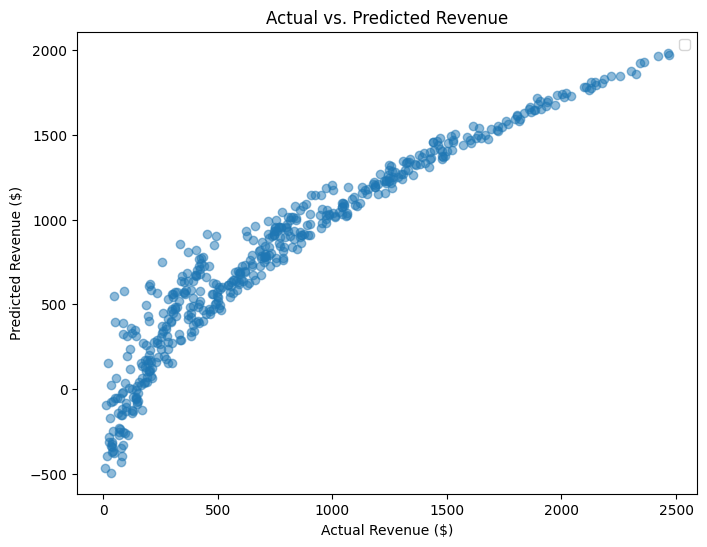

In [155]:
## the regression above is good enough, but i want to plot it visually to understand and see the relationship of the regression in addition to having the r squared and the coefficients above

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Actual Revenue ($)")
plt.ylabel("Predicted Revenue ($)")
plt.title("Actual vs. Predicted Revenue")
plt.legend()
plt.show()



**Linear regression takeaway**

The model achieved an R² of 0.897, meaning it explains 89.7% of the variation in transaction revenue across the dataset. This is a strong fit and confirms that we identified the most important drivers of revenue.
 

### Modeling Summary 

- **What were you trying to predict?** Total revenue per transaction, using the five variables identified as most important through the earlier part of the project: product price, quantity, discount percentage, VIP status, and a binary flag for whether any discount was applied.
- **What features did you use?** Product price, quantity, discount percentage, VIP status, and a binary flag for whether any discount was applied.
- **How did the model perform?** The model achieved an R² of 0.897, meaning it explains 89.7% of the variation in transaction revenue across the dataset. This is a strong fit and confirms that the EDA correctly identified the most important drivers of revenue.
- **What are the limitations?** This assumes each of the relationships with revenue are linear and the variables act independently and are not impacted by each other or also correlated. I used a full dataset without a train/test split. I also did not look at product or marketing channels.
- **Did the model help answer your main question?** Yes. Quantity and product price emerged as the strongest positive drivers, while this continues to reinforce that discounts were confirmed as the largest negative driver. VIP status had a near-zero effect.


 


**Thought the two tests were fine but i went back and revisited the rubric and it looks like train test split is a specific call out. after the t- tests have been done, adding in train test split to have conviction in the results and not just rely on my t test**


In [160]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Variables (predictors) and target
variables = ["product_price", "quantity", "discount_applied", "is_vip", "binary_discount"]
X = df_clean[variables]
y = df_clean["total_revenue"]

# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit the model on training data only
model = LinearRegression()
model.fit(X_train, y_train)
 
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
 
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Display coefficients
coefficients = pd.DataFrame({
    "Variable": variables,
    "Coefficient": model.coef_.round(2)
})


print(f"Training set size: {len(X_train)} transactions")
print(f"Test set size: {len(X_test)} transactions")
print(coefficients.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.2f}")
print(f"Training R Squared: {train_r2:.3f}")
print(f"Test R Squared:     {test_r2:.3f}")
print(f"Test MAE:    ${test_mae:.2f}")
print(f"Test RMSE:   ${test_rmse:.2f}")


Training set size: 400 transactions
Test set size: 100 transactions
        Variable  Coefficient
   product_price         2.86
        quantity       239.81
discount_applied      -872.07
          is_vip        -2.55
 binary_discount       -46.66

Intercept: -631.25
Training R Squared: 0.895
Test R Squared:     0.903
Test MAE:    $150.32
Test RMSE:   $198.50


**How train test split helped the analysis**
The model was trained on 400 transactions (80%) and evaluated on a held-out test set of 100 transactions (20%) it had never seen before. The test R squared is slightly higher than the training R squared, which indicates the model holds up with new data and isnt overfit. The MAE of $ 150 is a reasonable error band for a simple linear model when the average transaction revenue is approximately $ 770. The train test model does not counteract the outcomes of our t tests or linear regression variables with statistically significant relationships.


## 11. Final Project Summary


**1. Problem Statement**
This project analyzed transaction-level data for an e-commerce company to identify the top customer, product, and pricing levers the company should prioritize in FY 2026 to maximize revenue growth without eroding margin. The analysis was prepared for the CFO, CMO, and Head of Sales to inform the upcoming year's growth strategy.

**2. Dataset Used**
A 500-row, 13-column transaction dataset spanning one full year (January 2025 through January 2026). Each row represents a single transaction and includes customer identifiers and segments, product category and price, transaction quantity, discount status, marketing channel, region, total revenue, customer satisfaction, and return status. The dataset was cleaned and supplemented with five derived columns (month, is_weekend, revenue_per_unit, binary_discount, is_vip) to support the analysis. I never ended up using month.

**3. Main Analysis Steps**
- Data inspection and cleaning, including datetime conversion, missing value handling, and verification of categorical labels
- Visual single factor analysis of revenue drivers and customer segmentation 
- Group-based analysis across customer segments, product categories, marketing channels, weekday vs. weekend, and the cross-cut of VIP and discount status
- Relationship analysis using a correlation matrix and two t-tests 
- Predictive modeling using linear regression to quantify the dollar impact of each variable on revenue

**4. Key Insights**
- The current discount strategy is the company's largest issue. Discounts are applied to 67% of transactions and statistically reduce revenue without increasing volume.
- The current VIP designation does not capture behaviorally differentiated customers. Two independent statistical tests confirmed that VIP status has no measurable effect on revenue (by transaction or in overall volume).
- Marketing channel is the strongest acquisition lever. Product category showed no meaningful variation.
- Weekday timing does not matter. Weekday vs. weekend timing is not a meaningful revenue lever.

**5. Recommendations**
- **CFO:** Reduce overall discount frequency, particularly for VIP-labeled customers who are being discounted the most.
- **Head of Sales:** Audit how the VIP designation is being assigned and revisit the classification. The current label does not capture genuinely high-value customers.
- **CMO:** Scale investment in Paid Search and Social Media as the highest-yield acquisition channels. Do not change product category mix.

**6. Limitations**
- Single-year dataset; multi-year data would strengthen findings and surface seasonality
- Linear regression fit without a train/test split
- The VIP designation recommended above requires access to the original criteria used to assign the designation
- Single year is by far the biggest limitation. The VIP status is likely driven by multi-year relationship, so that needs to be tested on longer time horizon data before throwing out the designation.

**7. Future Work**
- Test discounts overall and with VIP customers to save revenue
- Redefine VIP criteria using behavioral data
- Rerun VIP statistical relationship on data with longer time horizon  


You should also save a short version of this summary in:

```text
docs/project_summary.md
```


## 11. Final Project Summary


**1. Problem Statement**
This project analyzed transaction-level data for an e-commerce company to identify the top customer, product, and pricing levers the company should prioritize in FY 2026 to maximize revenue growth without eroding margin. The analysis was prepared for the CFO, CMO, and Head of Sales to inform the upcoming year's growth strategy.

**2. Dataset Used**
A 500-row, 13-column transaction dataset spanning one full year (January 2025 through January 2026). Each row represents a single transaction and includes customer identifiers and segments, product category and price, transaction quantity, discount status, marketing channel, region, total revenue, customer satisfaction, and return status. The dataset was cleaned and supplemented with five derived columns (month, is_weekend, revenue_per_unit, binary_discount, is_vip) to support the analysis. I never ended up using month.

**3. Main Analysis Steps**
- Data inspection and cleaning, including datetime conversion, missing value handling, and verification of categorical labels
- Visual single factor analysis of revenue drivers and customer segmentation 
- Group-based analysis across customer segments, product categories, marketing channels, weekday vs. weekend, and the cross-cut of VIP and discount status
- Relationship analysis using a correlation matrix and two t-tests 
- Predictive modeling using linear regression to quantify the dollar impact of each variable on revenue

**4. Key Insights**
- The current discount strategy is the company's largest issue. Discounts are applied to 67% of transactions and statistically reduce revenue without increasing volume.
- The current VIP designation does not capture behaviorally differentiated customers. Two independent statistical tests confirmed that VIP status has no measurable effect on revenue (by transaction or in overall volume).
- Marketing channel is the strongest acquisition lever. Product category showed no meaningful variation.
- Weekday timing does not matter. Weekday vs. weekend timing is not a meaningful revenue lever.

**5. Recommendations**
- **CFO:** Reduce overall discount frequency, particularly for VIP-labeled customers who are being discounted the most.
- **Head of Sales:** Audit how the VIP designation is being assigned and revisit the classification. The current label does not capture genuinely high-value customers.
- **CMO:** Scale investment in Paid Search and Social Media as the highest-yield acquisition channels. Do not change product category mix.

**6. Limitations**
- Single-year dataset; multi-year data would strengthen findings and surface seasonality
- Linear regression fit without a train/test split
- The VIP designation recommended above requires access to the original criteria used to assign the designation
- Single year is by far the biggest limitation. The VIP status is likely driven by multi-year relationship, so that needs to be tested on longer time horizon data before throwing out the designation.

**7. Future Work**
- Test discounts overall and with VIP customers to save revenue
- Redefine VIP criteria using behavioral data
- Rerun VIP statistical relationship on data with longer time horizon  


You should also save a short version of this summary in:

```text
docs/project_summary.md
```


## 12. Final Notebook Checklist

Before submitting:

- [ ] Notebook runs from top to bottom without errors
- [ ] Problem statement is clear
- [ ] Dataset is loaded from a relative path
- [ ] Cleaning steps are documented
- [ ] At least 2 visualizations are included
- [ ] At least 2 insights are clearly explained
- [ ] Recommendations are tied to evidence
- [ ] Cleaned dataset is saved
- [ ] Project summary is completed
- [ ] Files are organized in the required repo structure
